# Chapter 3 Conway生命游戏

利用以下概念
+ 利用matplotlib imshow展示
+ 利用matplotlib 生成动画
+ 使用numpy
+ 将%运算符运用在边界条件
+ 设置值的随机分布

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

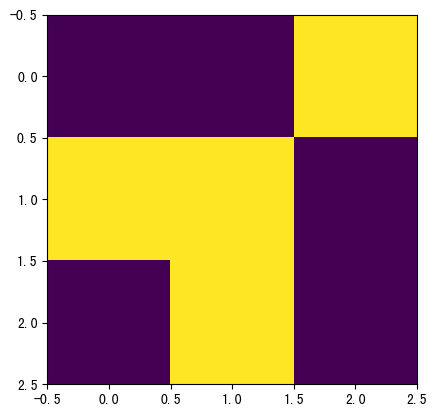

In [2]:
x= np.array([[0,0,255], [255,255,0], [0,255,0]])
plt.imshow(x,interpolation='nearest')
plt.show()

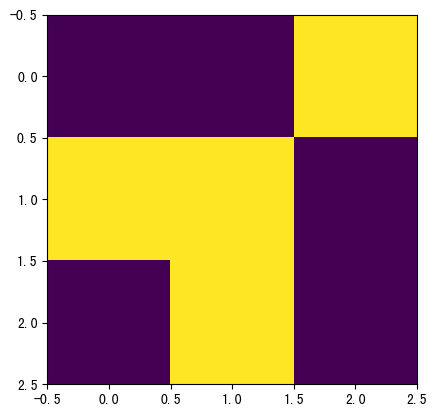

In [4]:
x= np.array([[0,0,255], [255,255,0], [0,255,0]])
plt.imshow(x)
plt.show()

In [5]:
np.random.choice([0,255], 4*4, p=[0.1,0.9]).reshape(4,4)

array([[255, 255, 255, 255],
       [255,   0, 255, 255],
       [255, 255, 255, 255],
       [255, 255, 255, 255]])

In [7]:
N = 6

In [9]:
def addGlider(i,j,grid):
    '''adds a glider with top left cell at (i,j)'''
    glider = np.array([[0,0,255],
                      [255,0,255],
                      [0,255,255]])
    grid[i:i+3, j:j+3] = glider

grid = np.zeros(N*N).reshape(N,N)
addGlider(1,1,grid)

In [10]:
grid

array([[  0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0., 255.,   0.,   0.],
       [  0., 255.,   0., 255.,   0.,   0.],
       [  0.,   0., 255., 255.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.]])

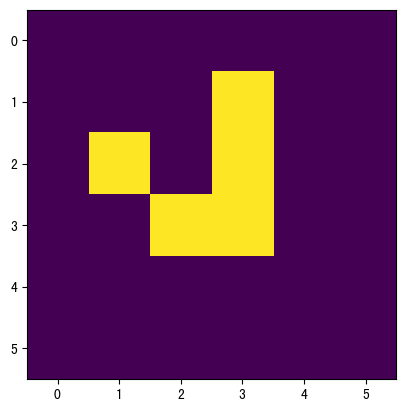

In [11]:
plt.imshow(grid)
plt.show()

# Chpater 4 用Karplus-Strong算法产生音乐泛音

**乐器的声音**
+ 基本频率
+ 泛音

在电脑上进行模拟，需利用Karpuls-Strong算法.

**学习以下几点**
+ 用python的deque类实现环形缓冲区
+ 用numpy数组和ufuncs
+ 用pygame播放wav文件
+ 用matplotlib绘图
+ 演奏五声音阶

## 创建wav文件

In [5]:
import numpy as np
import wave, math


# 次/秒
sRate = 44100

# 总次数
nSamples = sRate * 5

# 第几秒
x = np.arange(nSamples) / float(sRate)

# 220Hz = 震动次数/秒
# vals记录了每一次采样时震动了多少次
vals = np.sin(2.0*math.pi*220.0*x)
# data可能是放大处理
data = np.array(vals*32767, 'int16').tobytes()
# 写进文件
file = wave.open('sine220.wav', 'wb')
# 1 == 单通道    2 == 两字节    uncompresse == 无压缩
file.setparams((1,2,sRate, nSamples, 'NONE', 'uncompressed'))
file.writeframes(data)
file.close()

In [6]:
x.shape

(220500,)

In [7]:
nSamples

220500

In [8]:
x

array([0.00000000e+00, 2.26757370e-05, 4.53514739e-05, ...,
       4.99993197e+00, 4.99995465e+00, 4.99997732e+00])

## 小调五声音阶

|音符|赫兹(Hz)|
|--|--|
|C4|261.6|
|降E|311.1|
|F|349.2|
|G|392.0|
|降B|466.2|

## deque

In [11]:
from collections import deque
d = deque(range(1,10))
print(d)

deque([1, 2, 3, 4, 5, 6, 7, 8, 9])


In [12]:
d.append(-1)

In [13]:
d

deque([1, 2, 3, 4, 5, 6, 7, 8, 9, -1])

In [15]:
d.pop()

-1

In [16]:
d

deque([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [17]:
d.popleft()

1

In [18]:
d

deque([2, 3, 4, 5, 6, 7, 8, 9])

### 实现Karpuls-Strong算法

In [22]:
import random
import pygame

pygame 2.5.2 (SDL 2.28.3, Python 3.11.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [19]:
# generate note of given frequency
def generateNote(freq):
    '''
    freq: 音符本身的频率
    samleRate: 采样的频率
    N:　环形缓冲区的长度
    buf: 在[-0.5, 0.5]范围内的随机初始的长度为N的环形缓冲区
    samples: 初始化为全0的长度为nSamples的样本缓冲区
    '''
    nSamples = 44100
    sampleRate = 44100
    N = int(sampleRate/freq)
    # initialize ring buffer
    buf = deque([random.random() - 0.5 for i in range(N)])

    # initialze samples buffer
    samples = np.array([0]*nSamples, 'float32')
    # implement KS by loop
    for i in range(nSamples):
        samples[i] = buf[0]
        avg = 0.996 * 0.5*(buf[0]+buf[1])
        buf.append(avg)
        buf.popleft()

    # convert samples to 16-bit values and then to a string
    # the maximum value is 32767 for 16 bit
    samples = np.array(samples*32767, 'int16')
    return samples.tobytes()    

### 写入wav文件

In [20]:
def writeWAVE(fname, data):
    # open file
    file = wave.open(fname, 'wb')
    # WAV file params
    nChannels = 1
    sampleWidth = 2
    frameRate = 44100
    nFrames = 44100
    # set params
    file.setparams((nChannels, sampleWidth, frameRate, nFrames, 'NONE', 'noncompressed'))
    file.writeframes(data)
    file.close()

### 用pygame播放wav文件

In [23]:
# play a wav file
class NotePlayer:
    # constructor
    def __init__(self):
        pygame.mixer.pre_init(44100, -16, 1, 2048)
        pygame.init()
        # directory of notes
        self.notes = {}
    
    # add a note
    def add(self, fileName):
        self.notes[fileName] = pygame.mixer.Sound(fileName)

    # play a note
    def play(self, fileName):
        try:
            self.notes[fileName].play()
        except:
            print(f'{fileName} not found!')
    
    def playRandom(self):
        index = random.randint(0, len(self.notes)-1)
        note = list(self.notes.values())[index]
        note.play()
    

In [27]:
res = np.random.choice([1,2,4,8], 3, p=[0.15,0.7,0.1,0.05])

In [28]:
res

array([2, 1, 2])

# Chapter 5 类鸟群

**三个核心规则**
+ 分离： 保持类鸟个体之间的最小距离
+ 列队： 让每个个体指向离其局部同伴的平局移动方向
+ 内聚： 让每个个体朝其局部同伴的质量中心移动

当然也可以添加其他规则

**本章完成了**
+ 对于群体中的所有类鸟个体
    + 应用三大核心规则
    + 应用所有附加规则
    + 应用所有边界条件
+ 更新类鸟个体的位置和速度
+ 绘制新的位置和速度

**使用以下模块**
+ numpy数组，保存类鸟群的位置和速度
+ matplotlib，生成类鸟群动画
+ argparse， 处理命令行选项
+ scipy.spatial.distance，包含一些非常简洁的方法，计算点之间的距离

## 计算类鸟群的位置和速度

In [2]:
import math
import numpy as np


N = 5
width, height = 640, 480

pos = [width/2.0, height/2.0] + 10*np.random.rand(2*N).reshape(N,2)
angles = 2*math.pi*np.random.rand(N)
vel = np.array(list(zip(np.sin(angles), np.cos(angles))))

In [3]:
vel

array([[ 0.69095984,  0.72289315],
       [-0.51323068, -0.8582507 ],
       [ 0.99998997,  0.00447974],
       [ 0.53034273,  0.84778334],
       [ 0.14884069,  0.98886119]])

In [4]:
angles

array([0.76281598, 3.68053749, 1.56631658, 0.55900478, 0.1493958 ])

In [5]:
math.sin(0.7628158)

0.6909597045183798

In [6]:
math.cos(0.7628158)

0.7228932747867234

## 设置边界条件

In [ ]:
def applyBC(self):
    # apply boundary conditions
    deltaR = 2.0
    for coord in self.pos:
        if coord[0]  > width + deltaR:
            coord[0] = -deltaR
        if coord[0] < -deltaR:
            coord[0] = width + deltaR
        if coord[1]  > height + deltaR:
            coord[1] = -deltaR
        if coord[1] < -deltaR:
            coord[1] = height + deltaR

## 绘制类鸟群

**将类鸟群的个体化成两个圆，小圆是头，大圆是身体，满足：**
$$H = P + k\times V $$
H: center of the head  
P: center of the body  
k: constant  
V: velocity  

In [7]:
import matplotlib.pyplot as plt

In [8]:
import matplotlib.animation as animation

In [ ]:
# 画圆


fig = plt.figure()
ax = plt.axes(xlim=(0,width), ylim=(0,height))

pts, = ax.plot([],[], markersize=10,c='k', marker='o', ls='None')
beaks, = ax.plot([],[], markersize=4,c='r', marker='o', ls='None')
# there's no boids
# anim = animation.FuncAnimation(fig, tick, fargs=(pts,beak,boids), interval=50)

In [ ]:
# 更新位置

vec = self.pos  + 10 * self.vel / self.maxVel
beak.set_data(vec.reshape(2*self.N)[::2], vec.reshape(2*self.N)[1::2])

### 应用类鸟群的规则

In [12]:
from scipy.spatial.distance import squareform, pdist, cdist

In [13]:
x = np.array([[0.0,0.0], [1.0,1.0], [2.0,2.0]])

In [14]:
pdist(x)

array([1.41421356, 2.82842712, 1.41421356])

In [15]:
squareform(pdist(x))

array([[0.        , 1.41421356, 2.82842712],
       [1.41421356, 0.        , 1.41421356],
       [2.82842712, 1.41421356, 0.        ]])

In [16]:
squareform(pdist(x)) < 2

array([[ True,  True, False],
       [ True,  True,  True],
       [False,  True,  True]])